---
title: "Site Utilisation"
toc: true
execute:
  enabled: true
image: image.png
---

Every method in the [2SFCA example](../accessibility_2sfca/index.ipynb) and `site_allocation_summary()` (see the [comparing N sites example](../comparing_n_sites/index.ipynb)) answers a question about *reachable* or *allocated* supply -- how much supply is available given competition from other regions' demand, or how much demand a site would pick up under a solved solution. Both need a travel matrix, and the latter needs a solved solution.

This example answers a different, simpler question: **is this site already full *today*?** `site_utilisation_summary()` and `plot_site_utilisation()` report a site's real-world current load against its capacity, using only `candidate_sites` -- no demand data, no travel matrix, and no `solve()` required. It's a baseline diagnostic, not a model output.

## Setting up the problem

Same six Brighton sites as the [2SFCA example](../accessibility_2sfca/index.ipynb). The sample dataset has no real staffing or activity data, so as with that example's illustrative `gp_fte` column, we add two made-up columns here for demonstration: `weekly_capacity` (appointment slots per week) and `weekly_caseload` (slots actually booked). We'll imagine this is an average over the last 24 weeks. 

`add_sites(current_load_col=..., capacity_col=...)` registers both -- `current_load_col` always needs `capacity_col` alongside it, since a raw count on its own can't be turned into a ratio.

In [1]:
import geopandas as gpd
from lokigi.site import SiteProblem

sites_gdf = gpd.read_file("../../../sample_data/brighton_sites_named.geojson")

# Illustrative weekly appointment capacity and current caseload -- made up for
# demonstration, since the sample dataset has no real activity data.
sites_gdf["weekly_capacity"] = [120, 80, 200, 90, 110, 150]
sites_gdf["weekly_caseload"] = [95, 80, 240, 50, 70, 100]

problem = SiteProblem()

problem.add_sites(
    sites_gdf,
    candidate_id_col="site",
    capacity_col="weekly_capacity",
    current_load_col="weekly_caseload",
    )

## Raw counts: current load and capacity

`site_utilisation_summary()` derives `utilisation_ratio` (`current_load / capacity`) and `headroom` (`capacity - current_load`) for every site. Sorting by `utilisation_ratio` surfaces the fullest sites first.

In [2]:
summary = problem.site_utilisation_summary()
summary.sort_values("utilisation_ratio", ascending=False)

,capacity,current_load,utilisation_ratio,headroom
site,,,,
Tulip (Site 3),200,240,1.200000,-40
Begonia (Site 2),80,80,1.000000,0
Dahlia (Site 1),120,95,0.791667,25
Snowdrop (Site 6),150,100,0.666667,50
Daffodil (Site 5),110,70,0.636364,40
Daisy (Site 4),90,50,0.555556,40


Tulip is booked at 120% of its weekly capacity (`headroom` of -40 slots) and Begonia is running exactly full (`headroom` of 0) -- both would be strong candidates for extra provision before considering any new site. `utilisation_ratio`/`headroom` are left as-is above 1.0 rather than clipped, since a genuinely over-capacity site is itself the finding.

A site with no registered load or capacity at all (typically: a proposed site that isn't built yet) would appear as an explicit `NaN` row here rather than `0.0` -- a real `0.0` would misleadingly read as "measured, and currently idle".

## An alternative input shape: a precomputed ratio

Not every analyst will have raw current-load/capacity counts to hand -- sometimes all that's available is a utilisation percentage someone has already worked out. `add_sites(utilisation_col=...)` supports that shape directly, and is mutually exclusive with `current_load_col`.

In [3]:
# Same six sites, registered instead with a single precomputed ratio and no raw
# counts -- e.g. a percentage an analyst already had to hand.
sites_gdf["utilisation_pct"] = (
    sites_gdf["weekly_caseload"] / sites_gdf["weekly_capacity"]
    )

ratio_only_problem = SiteProblem()
ratio_only_problem.add_sites(
    sites_gdf,
    candidate_id_col="site",
    utilisation_col="utilisation_pct",
    )

ratio_only_problem.site_utilisation_summary().sort_values(
    "utilisation_ratio", ascending=False
    )

,utilisation_ratio
site,
Tulip (Site 3),1.200000
Begonia (Site 2),1.000000
Dahlia (Site 1),0.791667
Snowdrop (Site 6),0.666667
Daffodil (Site 5),0.636364
Daisy (Site 4),0.555556


Without a registered `capacity_col`, the result is narrower: no `capacity`, no `current_load`, and no `headroom` -- there's nothing to derive them from. Pairing `utilisation_col` with `capacity_col` (rather than `current_load_col`) still derives `headroom` (as `capacity * (1 - utilisation_ratio)`), just without a `current_load` column, since no raw caseload was registered.

In [4]:
ratio_and_capacity_problem = SiteProblem()
ratio_and_capacity_problem.add_sites(
    sites_gdf,
    candidate_id_col="site",
    capacity_col="weekly_capacity",
    utilisation_col="utilisation_pct",
    )

ratio_and_capacity_problem.site_utilisation_summary().sort_values(
    "utilisation_ratio", ascending=False
    )

,capacity,utilisation_ratio,headroom
site,,,
Tulip (Site 3),200,1.200000,-40.0
Begonia (Site 2),80,1.000000,0.0
Dahlia (Site 1),120,0.791667,25.0
Snowdrop (Site 6),150,0.666667,50.0
Daffodil (Site 5),110,0.636364,40.0
Daisy (Site 4),90,0.555556,40.0


## Mapping utilisation

`plot_site_utilisation()` colours and sizes each site marker by `utilisation_ratio` -- deliberately the *reverse* of `plot_accessibility()`'s site markers in the 2SFCA example. There, a high ratio is good (green, drawn large); here, a high ratio is bad (red, and *also* drawn large, so a hotspot is easy to spot on the map rather than shrinking out of view).

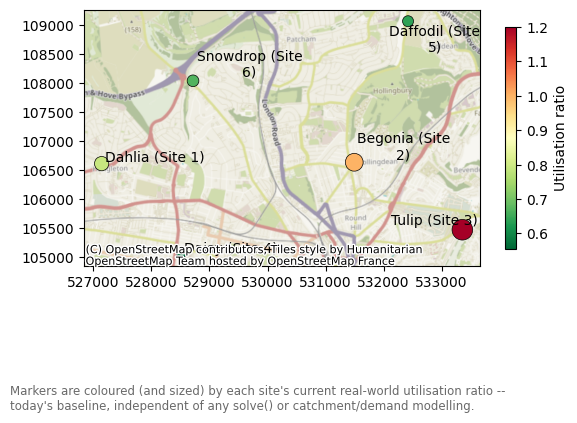

In [5]:
problem.plot_site_utilisation(add_basemap=True, show_labels=True);

Tulip and Begonia stand out immediately as the largest, reddest markers -- exactly the two sites already flagged above. 

`interactive=True` returns the same map as a Folium map, with a tooltip on every site.

In [6]:
problem.plot_site_utilisation(add_basemap=True, show_labels=True, interactive=True)

## Does the solution fit? Allocated demand vs capacity

Everything above treats capacity as a today's-baseline question, entirely independent of any solve. `site_capacity_summary()` (on `SiteSolutionSet`, not `SiteProblem`) asks a solve-derived question instead: for a *chosen* solution, does each selected site have room for the demand allocated to it? It builds directly on `site_allocation_summary()` (see the [comparing N sites example](../comparing_n_sites/index.ipynb)) plus the same `weekly_capacity`/`weekly_caseload` registered above, so we need demand data and a travel matrix -- neither registered yet -- and a solved solution to allocate regions with.

:::{.callout-warning}
lokigi does not yet support **capacitated** facility location -- there is no way to tell `solve()` "don't pick a combination that overloads a site's capacity". The `solve(p=3, ...)` call below picks its three sites purely on the travel-time objective (and `threshold_for_coverage`); capacity plays no part in which sites get selected.

`site_capacity_summary()` is a diagnostic that runs *after* the fact: it takes whatever solution `solve()` already settled on and checks whether the resulting allocation happens to fit. A solution can score well on travel time and still turn out to overload a site once you check its capacity -- as Daisy (Site 4) does below. If that happens, there is currently no automatic way to ask `solve()` for the next-best solution that avoids it; you would have to inspect the runner-up rows in `solutions.show_solutions()` and run `site_capacity_summary()` against each in turn.
:::

In [7]:
problem.add_demand(
    "../../../sample_data/brighton_demand.csv",
    demand_col="demand",
    location_id_col="LSOA"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving_named.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

solutions = problem.solve(p=3, threshold_for_coverage=8)

  0%|          | 0/20 [00:00<?, ?it/s]

`allocated_demand` is `site_allocation_summary()`'s own figure -- the population closest to each selected site under this solution. `allocated_utilisation_ratio` (`allocated_demand * demand_to_capacity_rate / capacity`) assumes that demand *replaces* today's caseload entirely, i.e. this is what the network would look like if it were rebuilt from scratch around this solution. `current_load`/`headroom`/`incremental_headroom_ratio` are also carried over from `site_utilisation_summary()`'s own registration, since we already registered `current_load_col` above -- `incremental_headroom_ratio` instead assumes the allocated demand lands *on top of* today's caseload (e.g. a new service line), which is a different and not necessarily compatible story. Neither assumption is universally right; which one applies depends on what the solution actually represents.

In [8]:
capacity_summary = solutions.site_capacity_summary()
capacity_summary.sort_values("allocated_utilisation_ratio", ascending=False)

,n_regions,allocated_demand,allocated_load,capacity,allocated_utilisation_ratio,current_load,headroom,incremental_headroom_ratio,residual_headroom
site,,,,,,,,,
Daisy (Site 4),66,127759,127759.0,90,1419.544444,50,40,3193.975,-127719.0
Tulip (Site 3),59,139817,139817.0,200,699.085000,240,-40,-3495.425,-139857.0
Daffodil (Site 5),40,61957,61957.0,110,563.245455,70,40,1548.925,-61917.0


`allocated_demand` above is in population units (people), while `weekly_capacity` is in appointment slots per week -- directly dividing one by the other, as `allocated_utilisation_ratio` does by default, silently assumes 1 appointment per person, which is not a real conversion. `demand_to_capacity_rate` converts between the two explicitly: if, say, 0.1% of the population in a site's catchment books an appointment there in a given week, that's `demand_to_capacity_rate=0.001`.

In [9]:
capacity_summary_adjusted = solutions.site_capacity_summary(demand_to_capacity_rate=0.001)
capacity_summary_adjusted.sort_values("allocated_utilisation_ratio", ascending=False)

,n_regions,allocated_demand,allocated_load,capacity,allocated_utilisation_ratio,current_load,headroom,incremental_headroom_ratio,residual_headroom
site,,,,,,,,,
Daisy (Site 4),66,127759,127.759,90,1.419544,50,40,3.193975,-87.759
Tulip (Site 3),59,139817,139.817,200,0.699085,240,-40,-3.495425,-179.817
Daffodil (Site 5),40,61957,61.957,110,0.563245,70,40,1.548925,-21.957


At this rate, Daisy is the one over capacity (`allocated_utilisation_ratio` 1.42) if this three-site solution replaced today's network entirely -- despite being the *least* full site in today's baseline utilisation table above. Tulip, today's most over-capacity site, actually has room to spare under this solution (0.70): a three-site network draws a different, larger catchment around it than its current caseload reflects. `incremental_headroom_ratio` tells a different story again -- it's negative for Tulip (-3.50), since its `headroom` is already negative today (it's over capacity *before* any of this solution's demand is added), so no allocation is absorbable there under that assumption at all.

:::{.callout-tip}
`demand_to_capacity_rate` isn't registered anywhere on the problem or the solution -- there's no `add_sites(demand_to_capacity_rate=...)` equivalent. It's a plain argument to whichever method you call, every time you call it, so it's easy to compute a corrected table once and then forget to pass the same rate into a plot -- each of `site_capacity_summary()`, `plot_site_capacity_summary()`, and `plot_allocated_utilisation()` defaults independently back to `1.0` if you don't.

That default silently assumes 1 appointment per person, which is exactly the wrong conversion here -- not an error, just a number nobody meant to compute. The tell is a chart where every bar dwarfs the "at capacity" reference line by two or three orders of magnitude (a bar at "141954%", say, rather than a plausible "142%") -- if you ever see that, the fix is almost always a missing or mismatched `demand_to_capacity_rate`, not a bug in the data.

The safest way to avoid this: compute the frame once with the rate applied, and pass *that* into every plot via `capacity_df=`, as the cells below do, rather than repeating `demand_to_capacity_rate=` at each call site:

```python
capacity_summary_adjusted = solutions.site_capacity_summary(demand_to_capacity_rate=0.001)
solutions.plot_site_capacity_summary(capacity_df=capacity_summary_adjusted)
solutions.plot_allocated_utilisation(capacity_df=capacity_summary_adjusted)
```
:::

## Plotting the fit

`plot_site_capacity_summary()` bars each site's ratio against a dashed "at capacity" reference line, colouring over-capacity bars distinctly from under-capacity ones -- semantically, not per-site, since the finding here is whether a site fits, not which site is which. Passing `capacity_df=capacity_summary_adjusted` (computed above) keeps the bars on that same, meaningful scale -- calling this with no `capacity_df` or `demand_to_capacity_rate` would recompute from scratch at the naive (and, as seen above, useless) default rate of `1.0`.

In [10]:
solutions.plot_site_capacity_summary(capacity_df=capacity_summary_adjusted)

Let's repeat this for the top 5 solutions. 

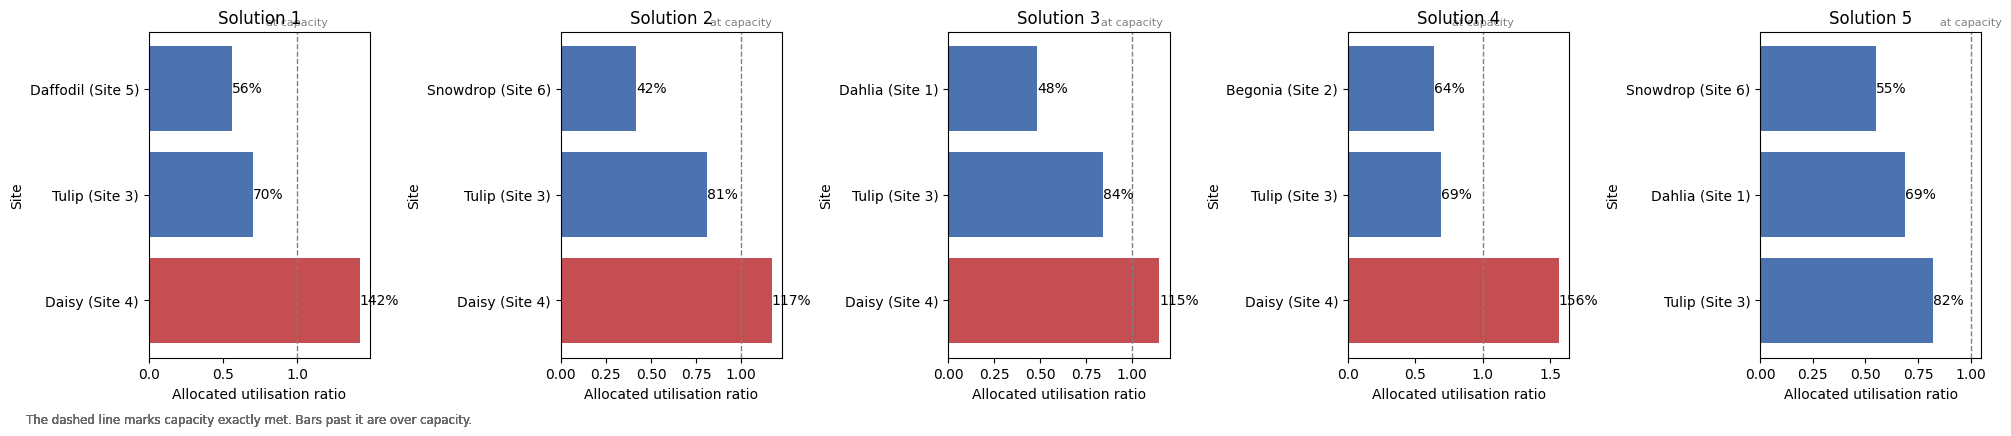

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)

for i, ax in enumerate(axes, start=1):
    solutions.plot_site_capacity_summary(
        interactive=False,
        demand_to_capacity_rate=0.001,
        solution_rank=i,
        ax=ax,
    )
    ax.set_title(f"Solution {i}")

plt.show()

## Mapping allocated utilisation

`plot_allocated_utilisation()` puts `site_capacity_summary()`'s `allocated_utilisation_ratio` on a map (again passing `capacity_df=capacity_summary_adjusted`), colouring and sizing markers the same way `plot_site_utilisation()` does above -- red and large for a stretched site. Unlike that map, only the sites *selected by this solution* are drawn: an unselected candidate would otherwise have to be shown grey, but grey already means "no capacity registered" here, and conflating "not chosen" with "chosen but not measured" would be actively misleading.

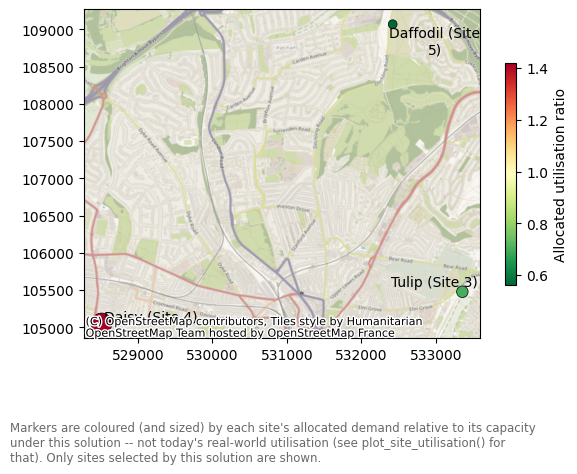

In [12]:
solutions.plot_allocated_utilisation(
    capacity_df=capacity_summary_adjusted, add_basemap=True, show_labels=True
    );

In [13]:
solutions.plot_allocated_utilisation(
    capacity_df=capacity_summary_adjusted, add_basemap=True, show_labels=True, interactive=True
    )

## Elsewhere in lokigi

- The [2SFCA example](../accessibility_2sfca/index.ipynb) answers a related but different question -- how much supply is *reachable* given competition from other regions' demand. That's catchment-derived and needs a travel matrix; this notebook's utilisation figures are today's real-world baseline, registered directly on `candidate_sites`.
- `site_allocation_summary()` (see the [comparing N sites example](../comparing_n_sites/index.ipynb)) answers a third, solve-derived question -- how much demand would this site pick up under a chosen solution. `site_capacity_summary()`, demonstrated above, is the bridge between that and this notebook's baseline: does the allocated demand actually fit within the registered capacity?
- The [evaluating an existing site combination example](../evaluating_current_baseline/index.ipynb) evaluates the current network's *travel* performance (coverage, average travel time); this one evaluates each site's current *load*. The two are complementary baselines for the same "before any changes" story.

:::{.callout-warning}
Worth repeating: none of this constrains `solve()`. lokigi has no capacitated search strategy yet -- `site_capacity_summary()` only checks a chosen solution's allocation against capacity *after* `solve()` has already picked it on travel-time grounds alone. It cannot rule out an over-capacity combination before it's selected, or ask `solve()` to search for one that fits better.
:::